In [1]:
import sys
from pathlib import Path
sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms\Graph-Vizualisation-Rating-Metric-randoms').resolve()))
# sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle
import os
# List of layouts
np.random.seed(212)


# Reading lambdas from corr

In [78]:
# coefficients = pd.read_csv(r'lambdas\ba_lasso.csv')
BA_features= pd.read_csv(r'lambdas\lasso_fixed_alpha_ba.csv')
BA_features.head()

,node_distribution,distance_to_borderlines_raw,edge_length_sum,edge_node_distance_contribution_raw,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,-0.485088,0.401644,0.0,-0.083192,-0.0,0.127135,0.0,-0.401795,BA


In [24]:
all_features = pd.read_csv(r'lambdas\lasso_fixed_alpha_all.csv')
all_features.head()

,node_distribution,distance_to_borderlines_raw,edge_length_sum,edge_node_distance_contribution_raw,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,-0.450356,0.008361,0.0,0.0,-0.107639,0.362875,0.0,-0.328763,All


In [4]:
# BA_features.iloc[:, :-1] = BA_features.iloc[:, :-1].applymap(lambda x: 0 if abs(x) < 0.2 else x)
# BA_features.head()


In [19]:
# # From abservation above
# BA_features.drop(columns=['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution',
#                       'count_edge_crossings_raw'], inplace=True, axis=1)

# BA_features.head()


In [21]:
# import joblib
# from sklearn.preprocessing import StandardScaler

#@ old version without scaling
# def calculate_metric(lambdas, G, posdf, print_raw=False):

# # what to leave  -> conclusions from correlation analysis and vibes
# # zostaje : node_distribtuion, distance_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw
#     raw_values = {
#         'node_distribution' : node_distribution(posdf),
#         'distance_to_borderlines_raw' : distance_to_borderlines_raw(posdf),
#         'edge_length_sum' : edge_length_sum(G, posdf),
#         'edge_node_distance_contribution_raw' : edge_node_distance_contribution_raw(G, posdf)[0],
#         'count_edge_crossings_raw' : count_edge_crossings_raw(G, posdf),
#         'communities_closeness' : intra_cluster_distance(G, posdf)['overall_sum'],
#         'sum_of_angles' : sum_of_angles(G, posdf),
#         'symmetry' : measure_graph_symmetry(G, posdf)
#     }
#     if print_raw:
#         print(raw_values)

#     values = raw_values.copy()

#     i=0
#     score=0
#     for col in lambdas.columns:
#         if col not in ['score', 'category']:
#             component = lambdas[col][0] * values[col]
#             values[col] = component
#             # print(f'{col} : {round(component, 2)}')
#             score += component
#             i+=1


#     print(f'SCORE: {round(score, 2)}')
#     return (score, values)

In [162]:
import joblib
from sklearn.preprocessing import StandardScaler

def calculate_metric(lambdas, G, posdf,category='BA',print_raw=False):

# what to leave  -> conclusions from correlation analysis and vibes
# zostaje : node_distribtuion, distance_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw
    raw_values = pd.DataFrame({
    'node_distribution': [node_distribution(posdf)],
    'distance_to_borderlines_raw': [distance_to_borderlines_raw(posdf)],
    'edge_length_sum': [edge_length_sum(G, posdf)],
    'edge_node_distance_contribution_raw': [edge_node_distance_contribution_raw(G, posdf)[0]],
    'count_edge_crossings_raw': [count_edge_crossings_raw(G, posdf)],
    'communities_closeness': [intra_cluster_distance(G, posdf)['overall_sum']],
    'sum_of_angles': [sum_of_angles(G, posdf)],
    'symmetry': [measure_graph_symmetry(G, posdf)]
})

    # scaler = joblib.load(fr'scaler/scaler_{category}.pkl')
    scaler = joblib.load(fr'scaler/scaler.pkl')

    values = scaler.transform(raw_values)
    columns = ['node_distribution', 'distance_to_borderlines_raw', 'edge_length_sum', 'edge_node_distance_contribution_raw', 'count_edge_crossings_raw', 'communities_closeness', 'sum_of_angles', 'symmetry']
    values = {columns[i]: values[0][i] for i in range(len(columns))}
    
    #if no scaling
    # values = raw_values.copy()
    # values = values.to_dict(orient='records')[0]

    if print_raw:
        print('RAW VALUES')
        print(raw_values)
        print('SCALED')
        print(values)
    i=0
    score=0
    for col in lambdas.columns:
        if col not in ['score', 'category']:
            component = lambdas[col][0] * values[col]*10
            values[col] = component
            # print(f'{col} : {round(component, 2)}')
            score += component
            i+=1


    print(f'SCORE: {round(score, 2)}')
    return (score, values)

In [147]:
def show_graph_stats(lambdas, G, posdf, category='BA', print_raw=False):
    (score, values) = calculate_metric(lambdas, G, posdf, category, print_raw)

    pos = {i: (row['X'], row['Y']) for i, row in posdf.iterrows()}

    metrics_text = f"--- SCORE: {score:.2f} --- \n \n"
    metrics_text += "\n".join([f"{key.replace('_', ' ')} : {value:.2f}" for key, value in values.items()])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={'width_ratios': [3, 1]})


#TODO change this to a prettier color
    nx.draw(G, pos=pos, with_labels=True, edge_color='gray',node_color='#6465A1', node_size=200, font_size=10, ax=ax1)
    ax2.text(0, .5, metrics_text, fontsize=10, ha='left', va='center', transform=ax2.transAxes)
    ax2.axis('off')  # Hide the axes

    plt.tight_layout()
    plt.show()
    return score

# Tests

In [129]:
with open(r'tests\graph_objects\graph_ER_1_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_ER_1_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_1_kamada_kawai.csv')


In [7]:
# nx.draw(G, pos=posdf)
# calculate_metric(BA_features, G, posdf)

In [8]:
# posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_1_kamada_kawai.csv')
# calculate_metric(coefficients, G, posdf_worse)

In [148]:
from IPython.display import display, HTML

def check_if_test_passed(better_score, worse_score):
    if better_score >= worse_score:
        display(HTML('<span style="color: green;">P A S S E D!</span>'))
    else:
        display(HTML('<span style="color: red;"> F A I L E D!</span>'))


In [ ]:
all_features = pd.read_csv(r'lambdas\lasso_fixed_alpha_all.csv')
BA_features= pd.read_csv(r'lambdas\lasso_fixed_alpha_ba.csv')


In [131]:
all_trained= pd.read_csv(r'lambdas\rgg_lasso.csv')


In [153]:
#
#!   ====== set the lambdas ======
coefficients = pd.read_csv(r'lambdas\all_lasso.csv')
category='All'

### Test 1

SCORE: 0.69


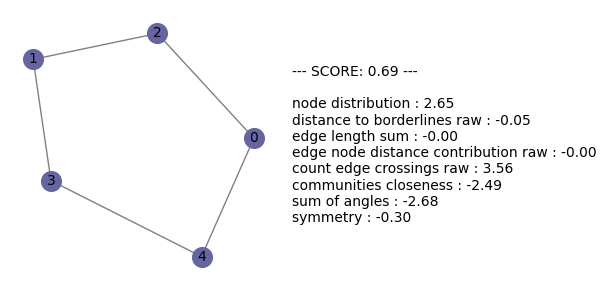

SCORE: 0.12


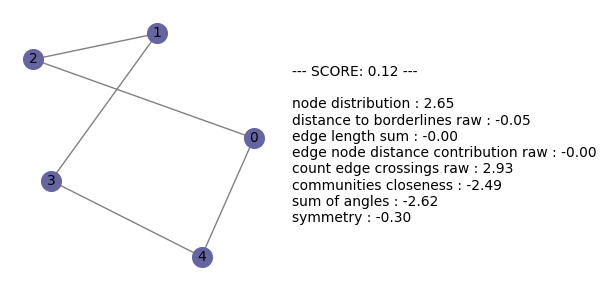

In [163]:
# nx.draw(G, pos=pos
better_score = show_graph_stats(coefficients, G, posdf, category)
worse_score = show_graph_stats(coefficients, G, posdf_worse, category)
check_if_test_passed(better_score, worse_score)

# test 2

RAW VALUES
   node_distribution  distance_to_borderlines_raw  edge_length_sum  \
0          51.184278                      121.456          1.79964   

   edge_node_distance_contribution_raw  count_edge_crossings_raw  \
0                            51.939949                         0   

   communities_closeness  sum_of_angles  symmetry  
0               7.964411       2.100414  0.919977  
SCALED
{'node_distribution': np.float64(-0.4816769796139928), 'distance_to_borderlines_raw': np.float64(-0.05277059260863144), 'edge_length_sum': np.float64(-0.700246557679781), 'edge_node_distance_contribution_raw': np.float64(-0.051718660318270694), 'count_edge_crossings_raw': np.float64(-0.7590237577238831), 'communities_closeness': np.float64(0.3402496527133495), 'sum_of_angles': np.float64(-0.668601339514729), 'symmetry': np.float64(-1.4740148640261628)}
SCORE: 8.97


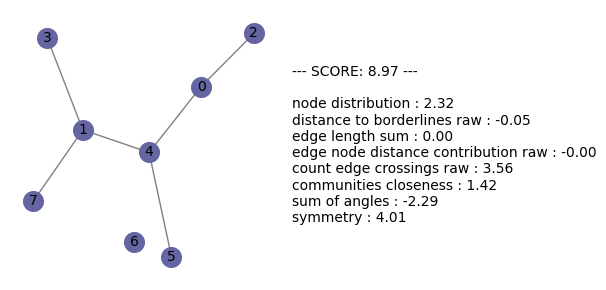

RAW VALUES
   node_distribution  distance_to_borderlines_raw  edge_length_sum  \
0           69.82916                      122.294         8.558887   

   edge_node_distance_contribution_raw  count_edge_crossings_raw  \
0                           136.842159                         4   

   communities_closeness  sum_of_angles  symmetry  
0               9.888284       2.135759  0.900742  
SCALED
{'node_distribution': np.float64(-0.45207235849722777), 'distance_to_borderlines_raw': np.float64(-0.05276967848912095), 'edge_length_sum': np.float64(1.2211989324861912), 'edge_node_distance_contribution_raw': np.float64(-0.050704244926852285), 'count_edge_crossings_raw': np.float64(-0.2249253648543025), 'communities_closeness': np.float64(0.7944152082406233), 'sum_of_angles': np.float64(-0.6630387494326324), 'symmetry': np.float64(-2.055083889174813)}
SCORE: 9.82


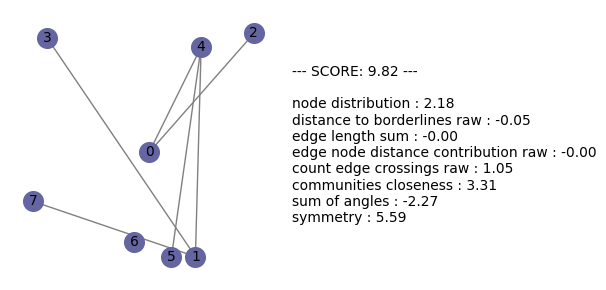

In [165]:
with open(r'tests\graph_objects\graph_ER_2_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_ER_2_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_2_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf, category, True)
w=show_graph_stats(coefficients, G, posdf_worse, category, True)
check_if_test_passed(b,w)

# BA 

### test 3

SCORE: 6.87


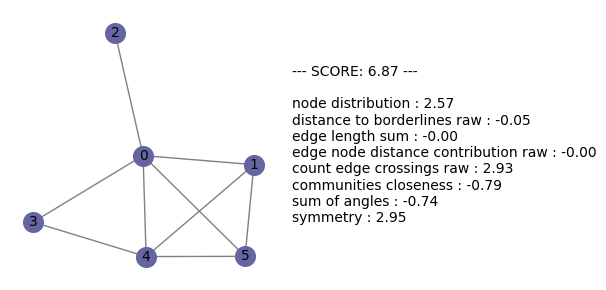

SCORE: 8.34


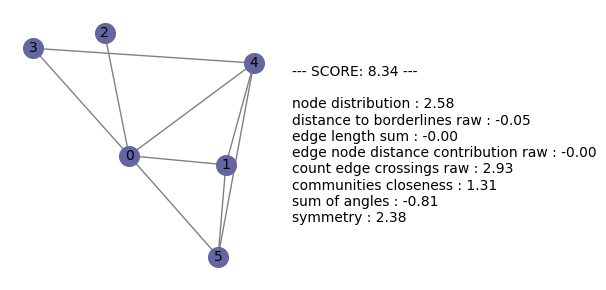

In [166]:
with open(r'tests\graph_objects\graph_BA_3_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_BA_3_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_BA_3_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf,  category)
w=show_graph_stats(coefficients, G, posdf_worse,  category)
check_if_test_passed(b,w)


### test 4


SCORE: 12.1


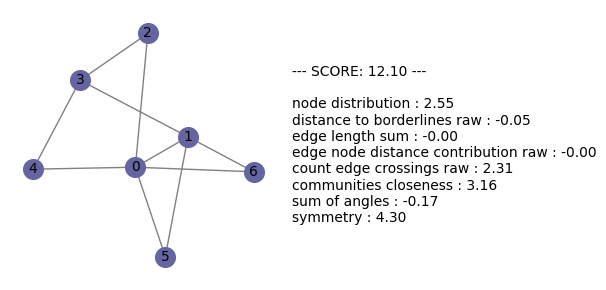

SCORE: 8.07


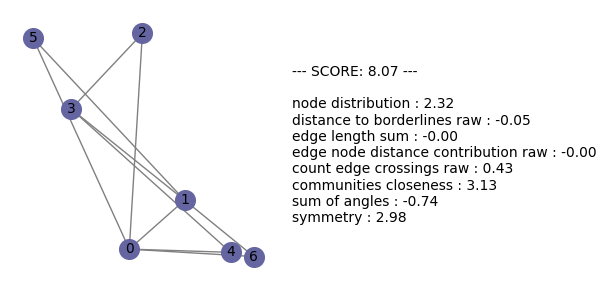

In [167]:
with open(r'tests\graph_objects\graph_BA_4_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_BA_4_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_BA_4_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf,  category)
w=show_graph_stats(coefficients, G, posdf_worse,  category)
check_if_test_passed(b,w)


# WS

SCORE: 12.31


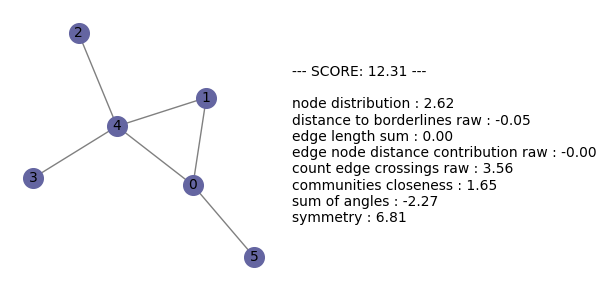

SCORE: 5.83


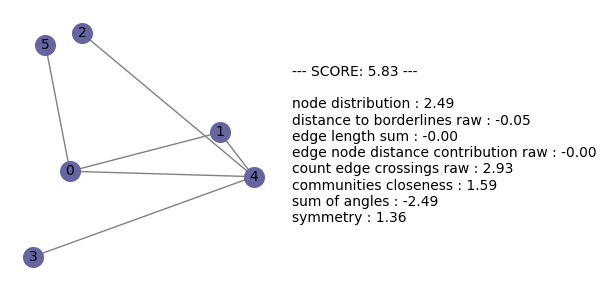

In [168]:
with open(r'tests\graph_objects\graph_WS_5_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_WS_5_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_WS_5_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf,  category)
w=show_graph_stats(coefficients, G, posdf_worse,  category)
check_if_test_passed(b,w)


SCORE: 9.68


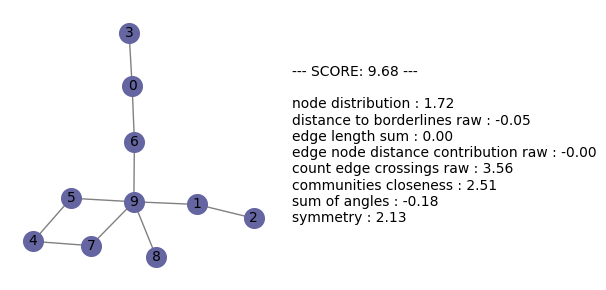

SCORE: 8.56


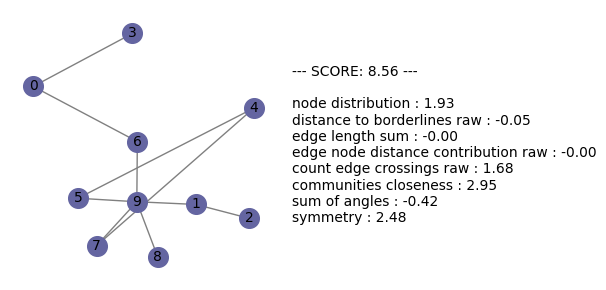

In [169]:
with open(r'tests\graph_objects\graph_WS_6_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_WS_6_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_WS_6_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf, category)
w=show_graph_stats(coefficients, G, posdf_worse, category)
check_if_test_passed(b,w)


# RGG

SCORE: 9.28


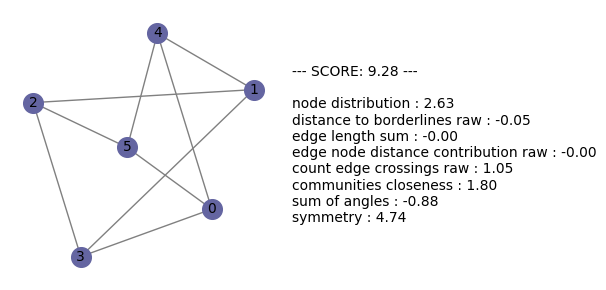

SCORE: 9.73


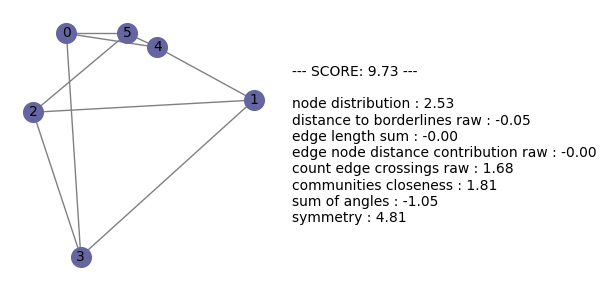

In [170]:
with open(r'tests\graph_objects\graph_RGG_7_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_RGG_7_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_RGG_7_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf, category)
w=show_graph_stats(coefficients, G, posdf_worse, category)
check_if_test_passed(b,w)



SCORE: 0.69


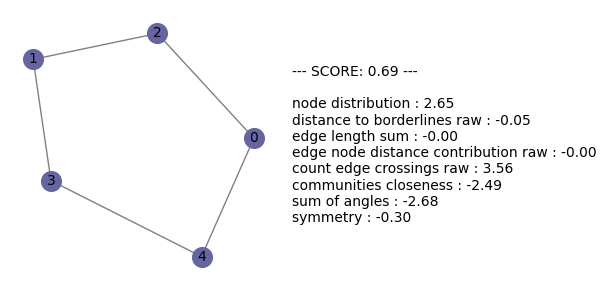

SCORE: 0.12


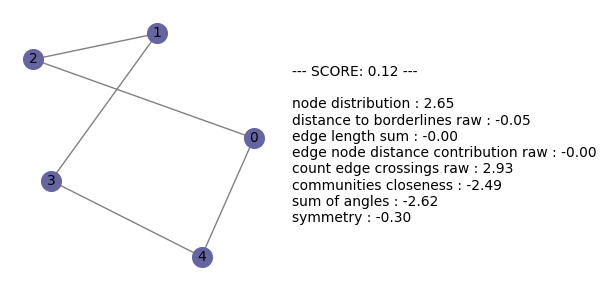

In [171]:
with open(r'tests\graph_objects\graph_RGG_8_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_RGG_8_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_RGG_8_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf,  category)
w=show_graph_stats(coefficients, G, posdf_worse,  category)
check_if_test_passed(b,w)

